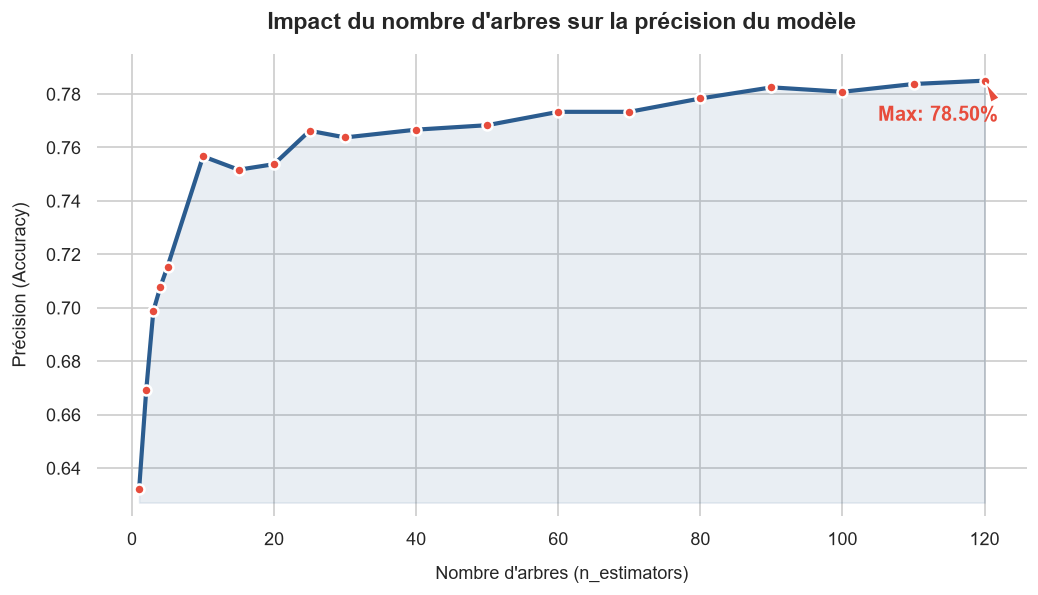

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_hastie_10_2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Données
X, y = make_hastie_10_2(n_samples=12000, random_state=808)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=8
)

# 2. Entraînement
tree_counts = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
accuracy = []

for n_estimator in tree_counts:
    # Légère augmentation de max_depth pour observer une meilleure convergence
    clf = RandomForestClassifier(
        n_estimators=n_estimator, max_depth=5, random_state=8
    )
    clf.fit(X_train, y_train)
    accuracy.append(clf.score(X_test, y_test))

# 3. Visualisation Seaborn / Matplotlib
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5), dpi=120)

plt.plot(
    tree_counts,
    accuracy,
    color="#2b5c8f",
    linewidth=2.5,
    marker="o",
    markersize=6,
    markerfacecolor="#e74c3c",
    markeredgecolor="white",
    markeredgewidth=1.5,
)

plt.fill_between(
    tree_counts, accuracy, min(accuracy) - 0.005, color="#2b5c8f", alpha=0.1
)

# Annotation du score maximal
best_acc = max(accuracy)
best_trees = tree_counts[accuracy.index(best_acc)]

plt.annotate(
    f"Max: {best_acc:.2%}",
    xy=(best_trees, best_acc),
    xytext=(best_trees - 15, best_acc - 0.015),
    arrowprops=dict(facecolor="#e74c3c", shrink=0.08, width=1, headwidth=6),
    fontweight="bold",
    color="#e74c3c",
)

# Habillage
plt.title(
    "Impact du nombre d'arbres sur la précision du modèle",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Nombre d'arbres (n_estimators)", fontsize=11, labelpad=10)
plt.ylabel("Précision (Accuracy)", fontsize=11, labelpad=10)

plt.ylim(min(accuracy) - 0.01, max(accuracy) + 0.01)
sns.despine(left=True, bottom=True)

plt.show()